In [1]:
from planning.planner import connect_poses_with_curvature, pose_to_node, node_to_pose, plan_from_path, a_star, create_graph, add_edges
import networkx as nx
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive
import math
import numpy as np

environment = [
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=2.9, ymin=0.0, xmax=3.0, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=2.9, xmax=3.0, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=0.1)
    ),
]

# Body: 2 rectangles (robot body)
body = [
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065)
    ),
]


ps = PlanningSetup(
            bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=3.0),
            max_linear_velocity_m_s=0.4,
            min_linear_velocity_m_s=-0.3,
            max_angular_velocity_deg_s=30.0,
            max_curvature=math.inf,
            tolerance_xy_m=0.05,
            tolerance_theta_deg=20.0,
            environment=environment,
            body=body
        )


start = FriendlyPose(1.5, 1.5, 0.0)
goal = FriendlyPose(1.1, 1.05, 0.0)


DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 2.4.6
DEBUG:dt_protocols:dt-protocols version 6.2.35 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_challenges:duckietown_challenges version 6.5.2 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_build_utils:duckietown_build_utils version 6.2.78 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_docker_utils:duckietown_docker_utils version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:ipce:version 6.1.2 path /usr/local/lib/python3.8/dist-packages


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose (FriendlyPose) and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        dt = 0.001
        n = max(1, int(duration / dt))
        for _ in range(n):
            if abs(w) < 1e-6:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

def plot_trajectory_from_path(plan, path):
    """
    Plots the continuous trajectory defined by the plans on the edges of the path.
    The line is blue if the vehicle moves forward, green if it moves backward.
    """
    start_node = path[0]
    start_pose = node_to_pose(start_node)
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg

    plt.figure(figsize=(6,6))
    xs_all, ys_all = [x], [y]  # For start/goal markers

    for step in plan:
        # Simulate this step only
        temp_pose = type(start_pose)(x, y, theta_deg)
        xs, ys, thetas = simulate_plan(temp_pose, [step])
        # Only plot the segment (not the repeated start)
        color = 'blue' if step.velocity_x_m_s > 0 else 'green'
        plt.plot(xs, ys, color=color)
        # Update for next step
        x, y, theta_deg = xs[-1], ys[-1], thetas[-1]
        xs_all.extend(xs[1:])  # skip the first point to avoid duplicates
        ys_all.extend(ys[1:])

    plt.scatter([xs_all[0], xs_all[-1]], [ys_all[0], ys_all[-1]], c='red', label="Start/Goal")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Planned Trajectory (from edge plans)")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

In [3]:
# Precomputed graph based solution

# graph = create_graph(ps, ps.bounds, environment)
# add_edges(graph, ps)

# path = nx.shortest_path(graph, pose_to_node(ps, start), pose_to_node(ps, goal), weight='weight')
# print(path)

# from planning.planner import plan_from_path
# plan = plan_from_path(graph, path)
# for i in range(len(plan)):
#     print(path[i])
#     print(plan[i])

# plot_trajectory_from_path(plan, path)
# print(sum([step.duration for step in plan]))

A star finished, 262 nodes visited


/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


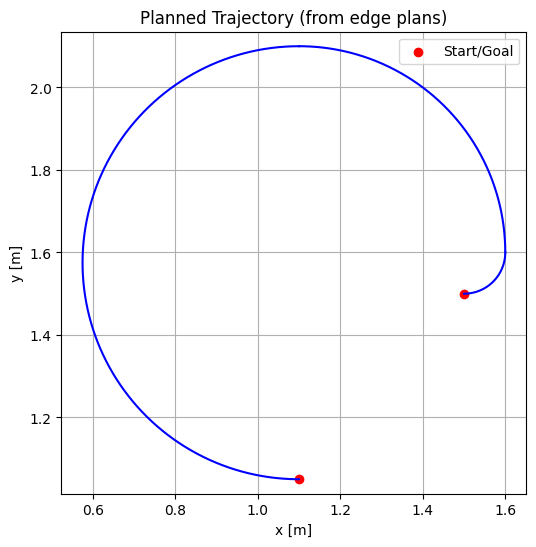

[(150, 150, 0), (160, 160, 90), (110, 210, 180), (110, 105, 0.0)]
[PlanStep(duration=3.0, velocity_x_m_s=0.0523598775598299, angular_velocity_deg_s=30.0), PlanStep(duration=3.0, velocity_x_m_s=0.2617993877991495, angular_velocity_deg_s=30.0), PlanStep(duration=6.0, velocity_x_m_s=0.2748893571891069, angular_velocity_deg_s=30.0)]
12.0


In [4]:
# A star
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))


A star finished, 96 nodes visited


/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


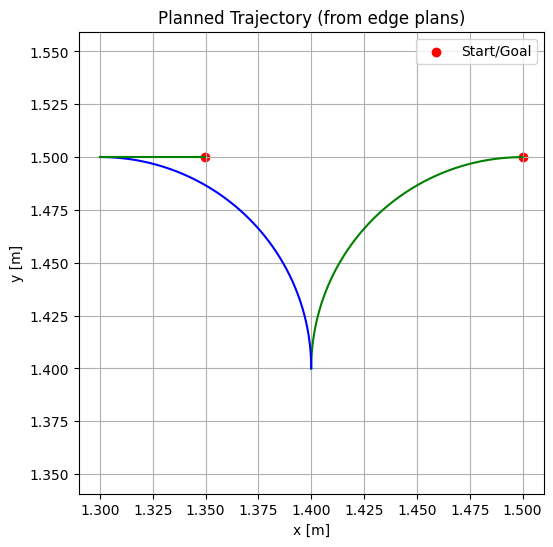

[(150, 150, 0), (140, 140, 90), (130, 150, 180), (135, 150, 180)]
[PlanStep(duration=3.0, velocity_x_m_s=-0.0523598775598299, angular_velocity_deg_s=30.0), PlanStep(duration=3.0, velocity_x_m_s=0.0523598775598299, angular_velocity_deg_s=30.0), PlanStep(duration=0.16666666666666682, velocity_x_m_s=-0.3, angular_velocity_deg_s=0.0)]
6.166666666666667


In [5]:
# A star
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.35, 1.5, 180)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

A star finished, 152 nodes visited


/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


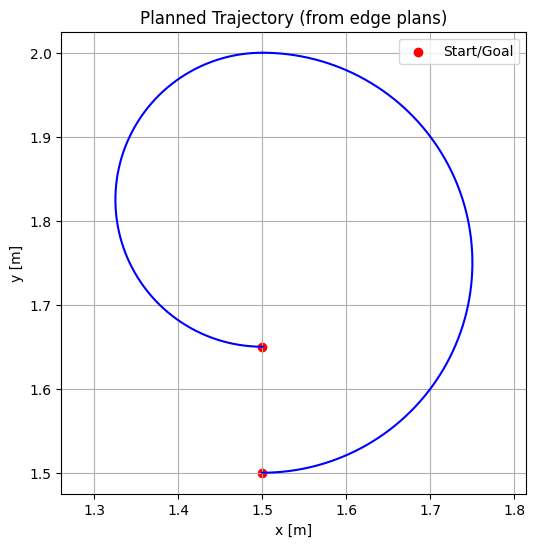

[(150, 150, 0), (150, 200, 180), (150, 165, 0.0)]
[PlanStep(duration=6.0, velocity_x_m_s=0.1308996938995747, angular_velocity_deg_s=30.0), PlanStep(duration=6.0, velocity_x_m_s=0.09162978572970232, angular_velocity_deg_s=30.0)]
12.0


In [6]:
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.5, 1.65, 0)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 89 nodes visited


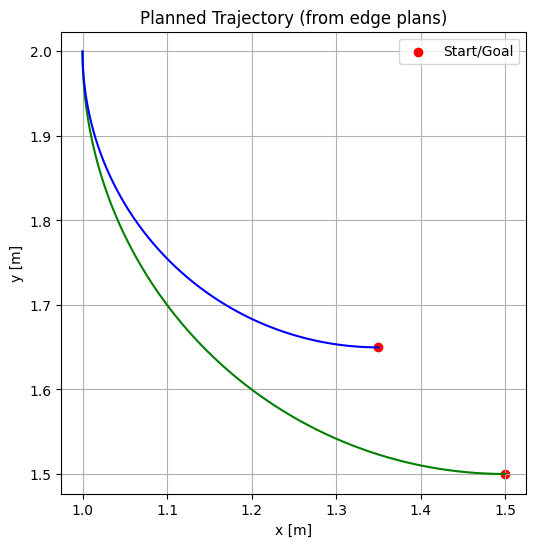

[(150, 150, 0), (100, 200, 270), (135, 165, 0.0)]
[PlanStep(duration=3.0, velocity_x_m_s=-0.2617993877991495, angular_velocity_deg_s=-30.0), PlanStep(duration=3.0, velocity_x_m_s=0.18325957145940466, angular_velocity_deg_s=30.0)]
6.0


In [7]:
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.35, 1.65, 0)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 15599 nodes visited


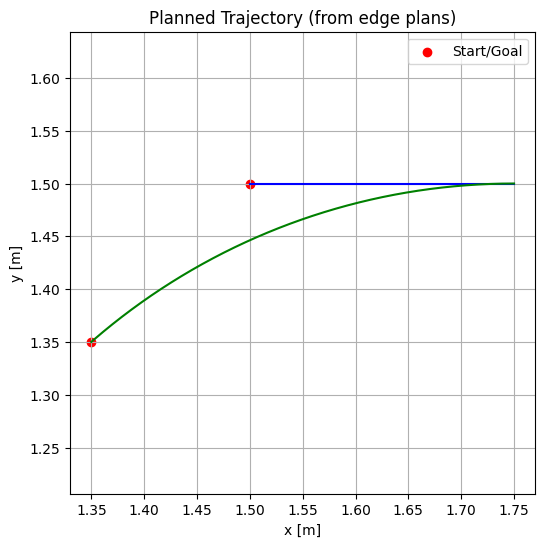

[(150, 150, 0), (175, 150, 0), (135, 135, 41.112090439166934)]
[PlanStep(duration=0.625, velocity_x_m_s=0.4, angular_velocity_deg_s=0.0), PlanStep(duration=1.4550143849862094, velocity_x_m_s=-0.3, angular_velocity_deg_s=28.25545291056115)]
2.0800143849862094


In [8]:
# Problem 1
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.35, 1.35, 45)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 17240 nodes visited


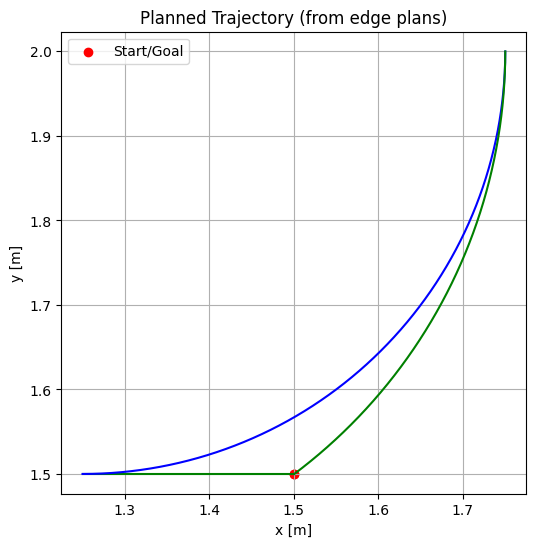

[(150, 150, 0), (125, 150, 0), (175, 200, 90), (150, 150, 36.86989764584402)]
[PlanStep(duration=0.8333333333333334, velocity_x_m_s=-0.3, angular_velocity_deg_s=0.0), PlanStep(duration=3.0, velocity_x_m_s=0.2617993877991495, angular_velocity_deg_s=30.0), PlanStep(duration=1.9318650375033586, velocity_x_m_s=-0.3, angular_velocity_deg_s=-27.501974166279517)]
5.765198370836692


In [9]:
# Problem 9
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.5, 1.5, 45)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

/code/planning/packages/planning/planner.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 16042 nodes visited


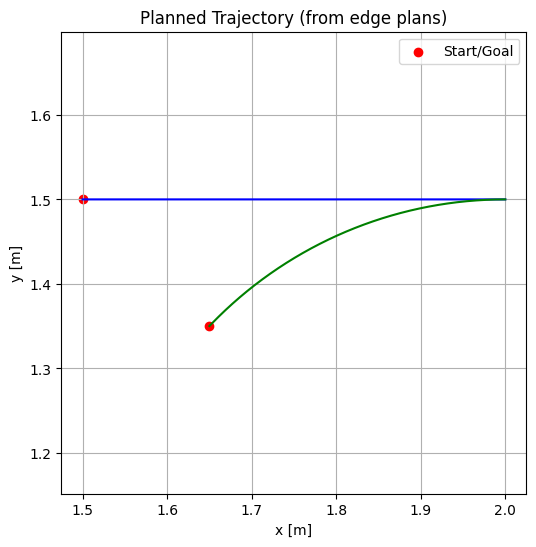

[(150, 150, 0), (200, 150, 0), (165, 135, 46.39718102729631)]
[PlanStep(duration=1.25, velocity_x_m_s=0.4, angular_velocity_deg_s=0.0), PlanStep(duration=1.546572700909877, velocity_x_m_s=-0.2530727415391781, angular_velocity_deg_s=30.0)]
2.796572700909877


In [10]:
# Problem 20
start = FriendlyPose(1.5, 1.5, 0)
goal = FriendlyPose(1.65, 1.35, 45)
plan, path = a_star(ps, start, goal)

if plan is not None:
    plot_trajectory_from_path(plan, path)

print(path)
print(plan)
print(sum([step.duration for step in plan]))